##  Data Cleaning and Processing - Indian Road Accident Dataset (2022–2025)
## Overview

The dataset was cleaned by handling missing values, removing duplicates, and converting data types. Categorical columns were standardized for consistency. Outlier detection was performed, and no significant outliers were found. The dataset is now ready for further analysis.

In [1]:
import pandas as pd
import numpy as np
df=pd.read_csv(r"C:\Users\Lenovo\OneDrive\Desktop\EDA project\data\indian_roads_dataset.csv")
df               

,accident_id,city,state,latitude,longitude,date,time,hour,day_of_week,is_weekend,...,visibility,temperature,traffic_density,cause,accident_severity,vehicles_involved,casualties,is_peak_hour,festival,risk_score
0,0,Pune,Maharashtra,18.680827,73.930388,2023-10-22,5:00,5,Sunday,1,...,low,32,high,weather,fatal,2,2,0,NaN,0.85
1,1,Mumbai,Maharashtra,18.817732,72.790846,2023-05-21,4:00,4,Sunday,1,...,high,34,low,weather,major,4,3,0,NaN,0.10
2,2,Mumbai,Maharashtra,19.096889,72.819424,2024-07-10,13:00,13,Wednesday,0,...,low,21,medium,weather,minor,1,1,0,NaN,0.45
3,3,Chandigarh,Punjab,30.787805,76.847507,2025-03-30,11:00,11,Sunday,1,...,low,30,high,distraction,minor,5,2,0,NaN,0.65
4,4,Chennai,Tamil Nadu,12.965155,80.283313,2024-01-25,16:00,16,Thursday,0,...,high,24,low,distraction,minor,2,1,0,NaN,0.10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19995,19995,Bangalore,Karnataka,13.092276,77.599571,2022-09-29,3:00,3,Thursday,0,...,high,31,low,distraction,minor,3,2,0,NaN,0.10
19996,19996,Chennai,Tamil Nadu,13.172928,80.157062,2023-11-25,1:00,1,Saturday,1,...,high,20,low,distraction,major,4,2,0,NaN,0.10
19997,19997,Chennai,Tamil Nadu,12.997170,80.150724,2022-06-18,15:00,15,Saturday,1,...,high,22,low,weather,minor,3,3,0,NaN,0.10
19998,19998,Kolkata,West Bengal,22.454882,88.322213,2023-03-12,4:00,4,Sunday,1,...,high,33,low,poor road,minor,1,0,0,NaN,0.10


In [35]:
df['date'] = pd.to_datetime(df['date'])
df['date']

0       2023-10-22
1       2023-05-21
2       2024-07-10
3       2025-03-30
4       2024-01-25
           ...    
19995   2022-09-29
19996   2023-11-25
19997   2022-06-18
19998   2023-03-12
19999   2024-07-05
Name: date, Length: 20000, dtype: datetime64[ns]

Convert the 'date' column into datetime format for time-based analysis.

In [4]:
df.isnull().sum()

accident_id              0
city                     0
state                    0
latitude                 0
longitude                0
date                     0
time                     0
hour                     0
day_of_week              0
is_weekend               0
road_type                0
lanes                    0
traffic_signal           0
weather                  0
visibility               0
temperature              0
traffic_density          0
cause                    0
accident_severity        0
vehicles_involved        0
casualties               0
is_peak_hour             0
festival             19885
risk_score               0
dtype: int64

Identify missing values in each column to understand data quality issues.

In [7]:
df['festival'] = df['festival'].fillna("No Festival")
df['festival'] 

0        No Festival
1        No Festival
2        No Festival
3        No Festival
4        No Festival
            ...     
19995    No Festival
19996    No Festival
19997    No Festival
19998    No Festival
19999    No Festival
Name: festival, Length: 20000, dtype: object

Handle missing values in the 'festival' column by filling them with 'No Festival'.

In [11]:
df.duplicated().sum()

np.int64(0)

Check for duplicate records in the dataset.

In [14]:
df.dtypes

accident_id                   int64
city                         object
state                        object
latitude                    float64
longitude                   float64
date                 datetime64[ns]
time                         object
hour                          int64
day_of_week                  object
is_weekend                    int64
road_type                    object
lanes                         int64
traffic_signal                int64
weather                      object
visibility                   object
temperature                   int64
traffic_density              object
cause                        object
accident_severity            object
vehicles_involved             int64
casualties                    int64
is_peak_hour                  int64
festival                     object
risk_score                  float64
dtype: object

Verify data types of each column and ensure they are appropriate.

In [39]:
df['weather'] = df['weather'].str.lower()
df['visibility'] = df['visibility'].str.lower()
df['traffic_density'] = df['traffic_density'].str.lower()
df['cause'] = df['cause'].str.lower()
df['accident_severity'] = df['accident_severity'].str.lower()


df['weather']
df['visibility'] 
df['traffic_density']
df['cause']
df['accident_severity']



0        fatal
1        major
2        minor
3        minor
4        minor
         ...  
19995    minor
19996    major
19997    minor
19998    minor
19999    minor
Name: accident_severity, Length: 20000, dtype: object

Standardize categorical columns by converting text to lowercase and removing extra spaces for consistency.

In [27]:
Q1 = df["casualties"].quantile(0.25)
Q3 = df["casualties"].quantile(0.75)

IQR = Q3 - Q1
lower= Q1 - 1.5*IQR
upper= Q3 + 1.5*IQR

outliers = df[(df["casualties"]  < lower) | (df["casualties"]>upper)]
outliers.shape




(0, 24)

In [37]:
Q1 = df["vehicles_involved"].quantile(0.25)
Q3 = df["vehicles_involved"].quantile(0.75)

IQR = Q3 - Q1
lower= Q1 - 1.5*IQR
upper= Q3 + 1.5*IQR

outliers = df[(df["vehicles_involved"]  < lower) | (df["vehicles_involved"]>upper)]
outliers.shape

(0, 24)

In [38]:
Q1 = df["temperature"].quantile(0.25)
Q3 = df["temperature"].quantile(0.75)

IQR = Q3 - Q1
lower= Q1 - 1.5*IQR
upper= Q3 + 1.5*IQR

outliers = df[(df["temperature"]  < lower) | (df["temperature"]>upper)]
outliers.shape

(0, 24)

## Outlier Analysis

Outlier detection was performed using the IQR method.

No significant outliers were found in the dataset for the selected numerical columns such as 'casualties', 'vehicles_involved', and 'temperature'.

Therefore, no rows were removed, and the dataset was retained as it is.

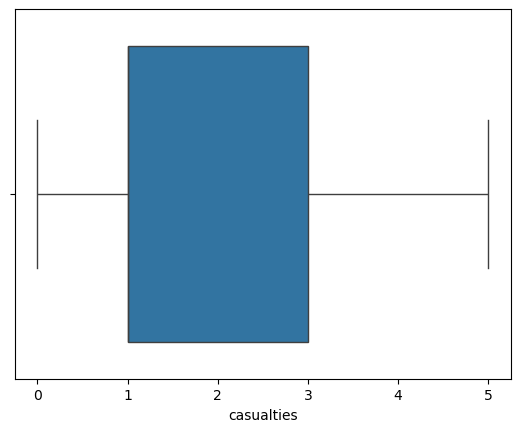

In [34]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x=df['casualties'])
plt.show()

In [11]:
df.to_csv(r"C:\Users\Lenovo\OneDrive\Desktop\EDA project\data\interim\cleaned_day2" , index=False)

## Cleaning Summary

Missing values were handled, duplicates were removed, and data types were corrected. Categorical columns were standardized for consistency. Outlier detection was performed, and no significant outliers were found. The cleaned dataset was saved for further analysis.